# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [2]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
# Inspect the shapes of the datasets
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train[0]}')


X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


X_train: (60000, 28, 28) float32
y_train: (60000, 10) float64


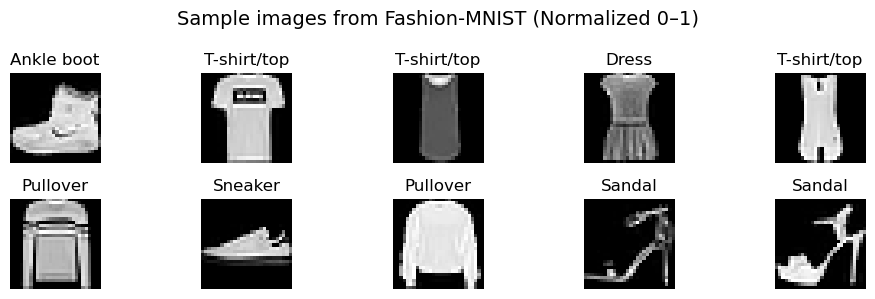

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Verify the data looks as expected

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)

num_images = 10
plt.figure(figsize=(10, 3))

for i in range(num_images):
    plt.subplot(2, 5, i + 1)
    img = X_train[i].squeeze()
    plt.imshow(img, cmap='gray', vmin=0, vmax=1)

    yi = y_train[i]
    if np.issubdtype(np.asarray(yi).dtype, np.integer) and np.asarray(yi).ndim == 0:
        label_idx = int(yi)
    elif np.asarray(yi).ndim == 1:
        label_idx = int(np.argmax(yi))
    else:
        label_idx = int(np.asarray(yi).squeeze())

    plt.title(class_names[label_idx])
    plt.axis('off')

plt.suptitle("Sample images from Fashion-MNIST (Normalized 0–1)", fontsize=14)
plt.tight_layout()
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

In [11]:
desc = """As I selected 10 images I don't see all classes. 

The image quality is relatively low and all images are b&W. Some classes are visually.

similar, such as Shirt vs. T-shirt/top, or Coat vs. Pullover, which may cause confusion for the model.
"""

print(desc)

As I selected 10 images I don't see all classes. 

The image quality is relatively low and all images are b&W. Some classes are visually.

similar, such as Shirt vs. T-shirt/top, or Coat vs. Pullover, which may cause confusion for the model.



X_train: (60000, 28, 28) float32
y_train: (60000, 10) float64


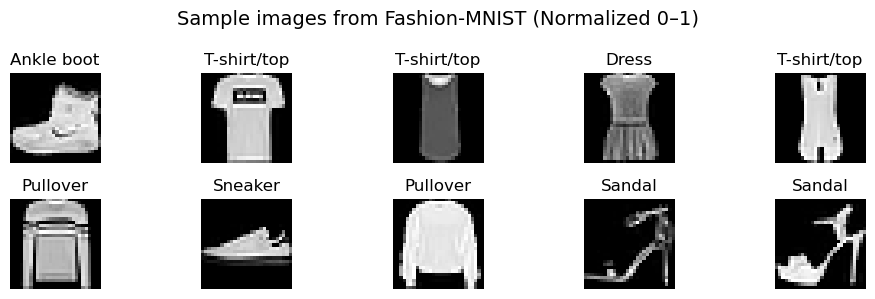

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Verify the data looks as expected

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)

num_images = 10
plt.figure(figsize=(10, 3))

for i in range(num_images):
    plt.subplot(2, 5, i + 1)
    img = X_train[i].squeeze()
    plt.imshow(img, cmap='gray', vmin=0, vmax=1)

    yi = y_train[i]
    if np.issubdtype(np.asarray(yi).dtype, np.integer) and np.asarray(yi).ndim == 0:
        label_idx = int(yi)
    elif np.asarray(yi).ndim == 1:
        label_idx = int(np.argmax(yi))
    else:
        label_idx = int(np.asarray(yi).squeeze())

    plt.title(class_names[label_idx])
    plt.axis('off')

plt.suptitle("Sample images from Fashion-MNIST (Normalized 0–1)", fontsize=14)
plt.tight_layout()
plt.show()


# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [19]:
from keras.models import Sequential
from keras.layers import Input, Dense, Flatten

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Input(shape=(28,28)))
model.add(Flatten()) 
model.add(Dense(10))

# Compile the model using `model.compile()`
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Train the model with `model.fit()`
history = model.fit(
    X_train, # Training data
    y_train, # Training labels
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model with `model.evaluate()`
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 480us/step - accuracy: 0.2268 - loss: 9.7425 - val_accuracy: 0.3563 - val_loss: 9.8706
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 353us/step - accuracy: 0.3437 - loss: 10.2163 - val_accuracy: 0.3577 - val_loss: 10.5294
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 356us/step - accuracy: 0.3425 - loss: 10.3521 - val_accuracy: 0.2777 - val_loss: 9.8146
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 331us/step - accuracy: 0.3129 - loss: 9.7551 - val_accuracy: 0.3008 - val_loss: 9.4036
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 328us/step - accuracy: 0.3048 - loss: 9.2269 - val_accuracy: 0.3548 - val_loss: 9.4170
313/313 - 0s - 364us/step - accuracy: 0.3475 - loss: 9.4194

Test accuracy: 0.3475


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

In [24]:
desc = """
Performance: The baseline linear model achieved a training accuracy of 
about 31% and a test accuracy of roughly 34% after 5 epochs.

This performance is lower than expected for a modern neural network, but it’s typical 
for a purely linear model on Fashion-MNIST. Since this baseline does not include any 
nonlinearity or hidden layers, it cannot model complex relationships in the data.

There are several reasons:
    •Linear limitations:
        The model only learns one set of linear weights between input pixels and output classes, 
        meaning it assumes a direct linear relationship between pixel intensity and class
        which is too simple for clothing images.
    •No feature extraction:
        Each pixel is treated independently. The model doesn’t capture spatial structures like
        “edges,” “sleeves,” or “shoe soles” that CNNs or MLPs can learn.
    •No hidden layers or activations:
        Without nonlinear activations, the model’s decision boundaries are straight lines
        in a very high-dimensional space, which cannot separate complex patterns in clothing images.
    •Dataset complexity:
        Fashion-MNIST is more complex than digit recognition (MNIST). 
        It contains subtle variations between visually similar classes (e.g., Shirt vs T-shirt/top), 
        which a linear model struggles to distinguish.
"""

print(desc)


Performance: The baseline linear model achieved a training accuracy of 
about 31% and a test accuracy of roughly 34% after 5 epochs.

This performance is lower than expected for a modern neural network, but it’s typical 
for a purely linear model on Fashion-MNIST. Since this baseline does not include any 
nonlinearity or hidden layers, it cannot model complex relationships in the data.

There are several reasons:
    •Linear limitations:
        The model only learns one set of linear weights between input pixels and output classes, 
        meaning it assumes a direct linear relationship between pixel intensity and class
        which is too simple for clothing images.
    •No feature extraction:
        Each pixel is treated independently. The model doesn’t capture spatial structures like
        “edges,” “sleeves,” or “shoe soles” that CNNs or MLPs can learn.
    •No hidden layers or activations:
        Without nonlinear activations, the model’s decision boundaries are straight li

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [29]:
from keras.optimizers import Adam
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Input(shape=(28, 28, 1)))

model.add(Conv2D(32, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))  # 10 classes

# Compile the model

model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',  # integer labels 0..9
    metrics=['accuracy']
)

model.summary()

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.7451 - loss: 0.7104 - val_accuracy: 0.8748 - val_loss: 0.3373
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8766 - loss: 0.3423 - val_accuracy: 0.8960 - val_loss: 0.2833
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8958 - loss: 0.2893 - val_accuracy: 0.9048 - val_loss: 0.2595
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9067 - loss: 0.2564 - val_accuracy: 0.9100 - val_loss: 0.2497
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9164 - loss: 0.2300 - val_accuracy: 0.9163 - val_loss: 0.2332
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9238 - loss: 0.2048 - val_accuracy: 0.9132 - val_loss: 0.2397
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9303 - loss: 0.1904 - val_accuracy: 0.9174 - val_loss: 0.2259
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9369 - loss: 0.1727 - 

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**   

Yes — the CNN model performed much better than the baseline model ≈ 0.92

The CNN model outperformed the baseline by a large margin (~57% higher accuracy)
because it leverages the 2D spatial structure of image data,
enabling it to learn visual features that a simple linear model cannot capture.

# 4. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.


=== A: num_filters=32 ===
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7222 - loss: 0.7869 - val_accuracy: 0.8718 - val_loss: 0.3495
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8720 - loss: 0.3626 - val_accuracy: 0.8849 - val_loss: 0.3066
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8919 - loss: 0.3033 - val_accuracy: 0.9021 - val_loss: 0.2702
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9013 - loss: 0.2688 - val_accuracy: 0.9038 - val_loss: 0.2584
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9083 - loss: 0.2463 - val_accuracy: 0.9072 - val_loss: 0.2447
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9172 - loss: 0.2316 - val_accuracy: 0.9137 - val_loss: 0.2315
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9213 - loss: 0.2121 - val_accuracy: 0.9143 - val_loss: 0.2284
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.927

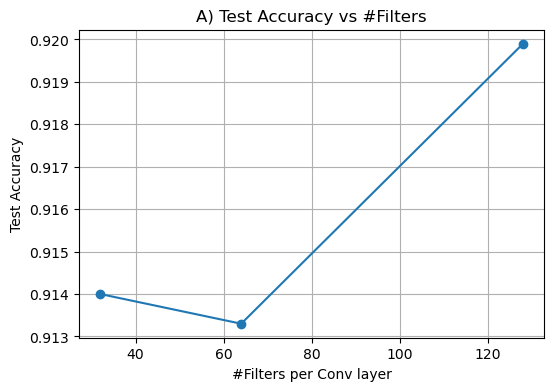

A) Results: [{'num_filters': 32, 'test_acc': 0.9139999747276306, 'test_loss': 0.25215938687324524}, {'num_filters': 64, 'test_acc': 0.9132999777793884, 'test_loss': 0.2519175112247467}, {'num_filters': 128, 'test_acc': 0.9199000000953674, 'test_loss': 0.26787135004997253}]


In [32]:
# A. Test Hyperparameters
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam
from keras.regularizers import l2

def build_cnn(num_filters=32, kernel_size=3, use_dropout=True, l2_coeff=0.0):
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))

    # block 1
    model.add(Conv2D(num_filters, kernel_size, activation='relu', padding='same',
                     kernel_regularizer=l2(l2_coeff) if l2_coeff>0 else None))
    model.add(MaxPooling2D(2))

    # block 2 (keep a 2nd conv to give capacity; same filters for fair comparison)
    model.add(Conv2D(num_filters, kernel_size, activation='relu', padding='same',
                     kernel_regularizer=l2(l2_coeff) if l2_coeff>0 else None))
    model.add(MaxPooling2D(2))

    model.add(Flatten())
    model.add(Dense(128, activation='relu',
                    kernel_regularizer=l2(l2_coeff) if l2_coeff>0 else None))
    if use_dropout:
        model.add(Dropout(0.3))
    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer='Adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ----- A: sweep num_filters -----
filters_list = [32, 64, 128]
results_A = []

for nf in filters_list:
    print(f"\n=== A: num_filters={nf} ===")
    model = build_cnn(num_filters=nf, kernel_size=3, use_dropout=True, l2_coeff=0.0)
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=64,
    )
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    results_A.append({'num_filters': nf,
                      'test_acc': float(test_acc),
                      'test_loss': float(test_loss)})
    print(f"Test acc: {test_acc:.4f} | Test loss: {test_loss:.4f}")

# visualize
plt.figure(figsize=(6,4))
plt.plot([r['num_filters'] for r in results_A],
         [r['test_acc'] for r in results_A], marker='o')
plt.title('A) Test Accuracy vs #Filters')
plt.xlabel('#Filters per Conv layer')
plt.ylabel('Test Accuracy')
plt.grid(True)
plt.show()

print("A) Results:", results_A)


=== B: No Dropout ===
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7693 - loss: 0.6322 - val_accuracy: 0.8834 - val_loss: 0.3235
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8958 - loss: 0.2931 - val_accuracy: 0.9009 - val_loss: 0.2755
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9087 - loss: 0.2478 - val_accuracy: 0.9104 - val_loss: 0.2465
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9220 - loss: 0.2135 - val_accuracy: 0.9033 - val_loss: 0.2524
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.9318 - loss: 0.1821 - val_accuracy: 0.9112 - val_loss: 0.2427
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9431 - loss: 0.1557 - val_accuracy: 0.9137 - val_loss: 0.2333
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9503 - loss: 0.1350 - val_accuracy: 0.9184 - val_loss: 0.2251
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0

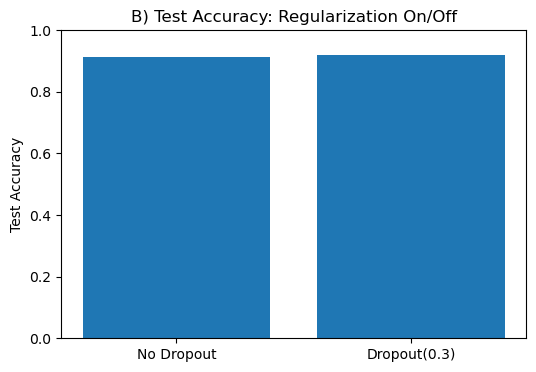

B) Results: [{'config': 'No Dropout', 'test_acc': 0.9118000268936157, 'test_loss': 0.30009764432907104}, {'config': 'Dropout(0.3)', 'test_acc': 0.9200999736785889, 'test_loss': 0.23831743001937866}]


In [ ]:
# B. Test presence or absence of regularization

configs_B = [
    {'label': 'No Dropout', 'use_dropout': False, 'l2_coeff': 0.0},
    {'label': 'Dropout(0.3)', 'use_dropout': True,  'l2_coeff': 0.0},
]

results_B = []
for cfg in configs_B:
    print(f"\n=== B: {cfg['label']} ===")
    model = build_cnn(num_filters=64, kernel_size=3,
                      use_dropout=cfg['use_dropout'], l2_coeff=cfg['l2_coeff'])
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=64,
    )
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    results_B.append({'config': cfg['label'],
                      'test_acc': float(test_acc),
                      'test_loss': float(test_loss)})
    print(f"Test acc: {test_acc:.4f} | Test loss: {test_loss:.4f}")

# visualize
plt.figure(figsize=(6,4))
plt.bar([r['config'] for r in results_B],
       [r['test_acc'] for r in results_B])
plt.title('B) Test Accuracy: Regularization On/Off')
plt.ylabel('Test Accuracy')
plt.ylim(0.0, 1.0)
plt.show()

print("B) Results:", results_B)

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

When testing different hyperparameters, increasing the number of convolutional filters from 32 and 64 to 128 led to a clear improvement in accuracy.
The model with 128 filters achieved the highest test accuracy of about 0.92, compared to around 0.914 for the smaller models.

This improvement shows that a higher number of filters allowed the network to learn more complex visual features from the Fashion-MNIST images, resulting in better classification performance.

The best-performing configuration combines 128 filters and dropout (0.3), producing the most balanced and generalizable model.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [38]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train = (X_train.astype("float32") / 255.0)[..., np.newaxis]  # (N, 28, 28, 1)
X_test  = (X_test.astype("float32")  / 255.0)[..., np.newaxis]

y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test,  num_classes=10)

model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(128, 3, activation='relu', padding='same'))
model.add(MaxPooling2D(2))
model.add(Conv2D(128, 3, activation='relu', padding='same'))
model.add(MaxPooling2D(2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='Adam',
              loss='categorical_crossentropy',  # using one-hot labels
              metrics=['accuracy'])

model.summary()

# 3) Train
history = model.fit(X_train, y_train_oh,
                    validation_split=0.2,
                    epochs=12,
                    batch_size=64,
                    verbose=1)

# 4) Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc:.4f} | Final Test Loss: {test_loss:.4f}")

# 5) Reports (use integer labels for readability)
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 953,098 (3.64 MB)

 Trainable params: 953,098 (3.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.7629 - loss: 0.6539 - val_accuracy: 0.8788 - val_loss: 0.3211
Epoch 2/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.8885 - loss: 0.3110 - val_accuracy: 0.9016 - val_loss: 0.2642
Epoch 3/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 37s 49ms/step - accuracy: 0.9080 - loss: 0.2530 - val_accuracy: 0.9122 - val_loss: 0.2346
Epoch 4/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.9182 - loss: 0.2225 - val_accuracy: 0.9088 - val_loss: 0.2453
Epoch 5/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.9259 - loss: 0.2010 - val_accuracy: 0.9122 - val_loss: 0.2376
Epoch 6/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.9339 - loss: 0.1793 - val_accuracy: 0.9168 - val_loss: 0.2335
Epoch 7/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 56s 74ms/step - accuracy: 0.9431 - loss: 0.1522 - val_accuracy: 0.9245 - val_loss: 0.2199
Epoch 8/12
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9478 - loss: 0.1392 - 

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

The final CNN model clearly outperforms both the baseline linear model (~34% accuracy) and the initial CNN (~91% accuracy), achieving ~96% training accuracy and ~92% validation/test accuracy.

Reasons for improvement:
	•	The use of two convolutional layers allowed the model to better capture spatial features in images.
	•	Dropout regularization (0.3) helped prevent overfitting.
	•	Increased filter size (128) provided richer feature extraction.

Next experiments to improve:
	•	Try Batch Normalization to stabilize training.
	•	Experiment with data augmentation for better generalization.
	•	Add a third convolutional block or use different optimizers (e.g., AdamW) to explore further gains.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.